# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [2]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1015/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1015/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


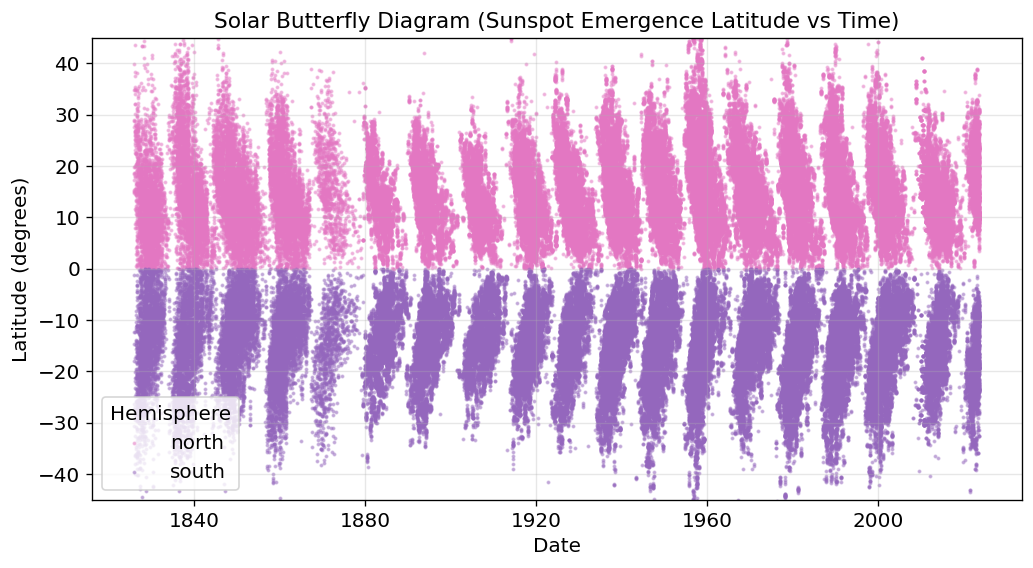

In [17]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:pink", "south": "tab:purple"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


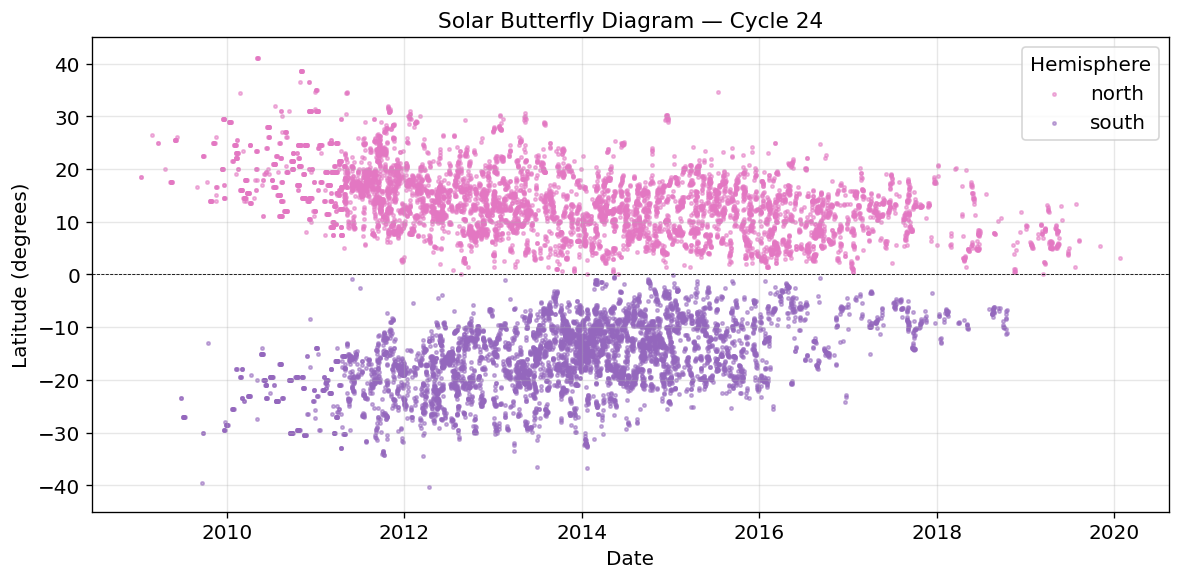

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [18]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_1015/3622672626.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


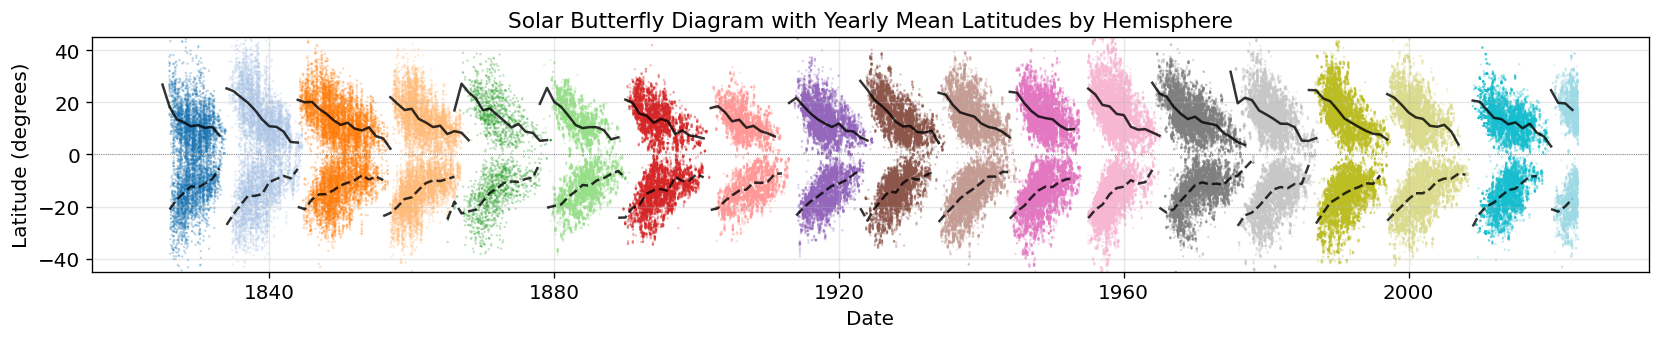

In [19]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

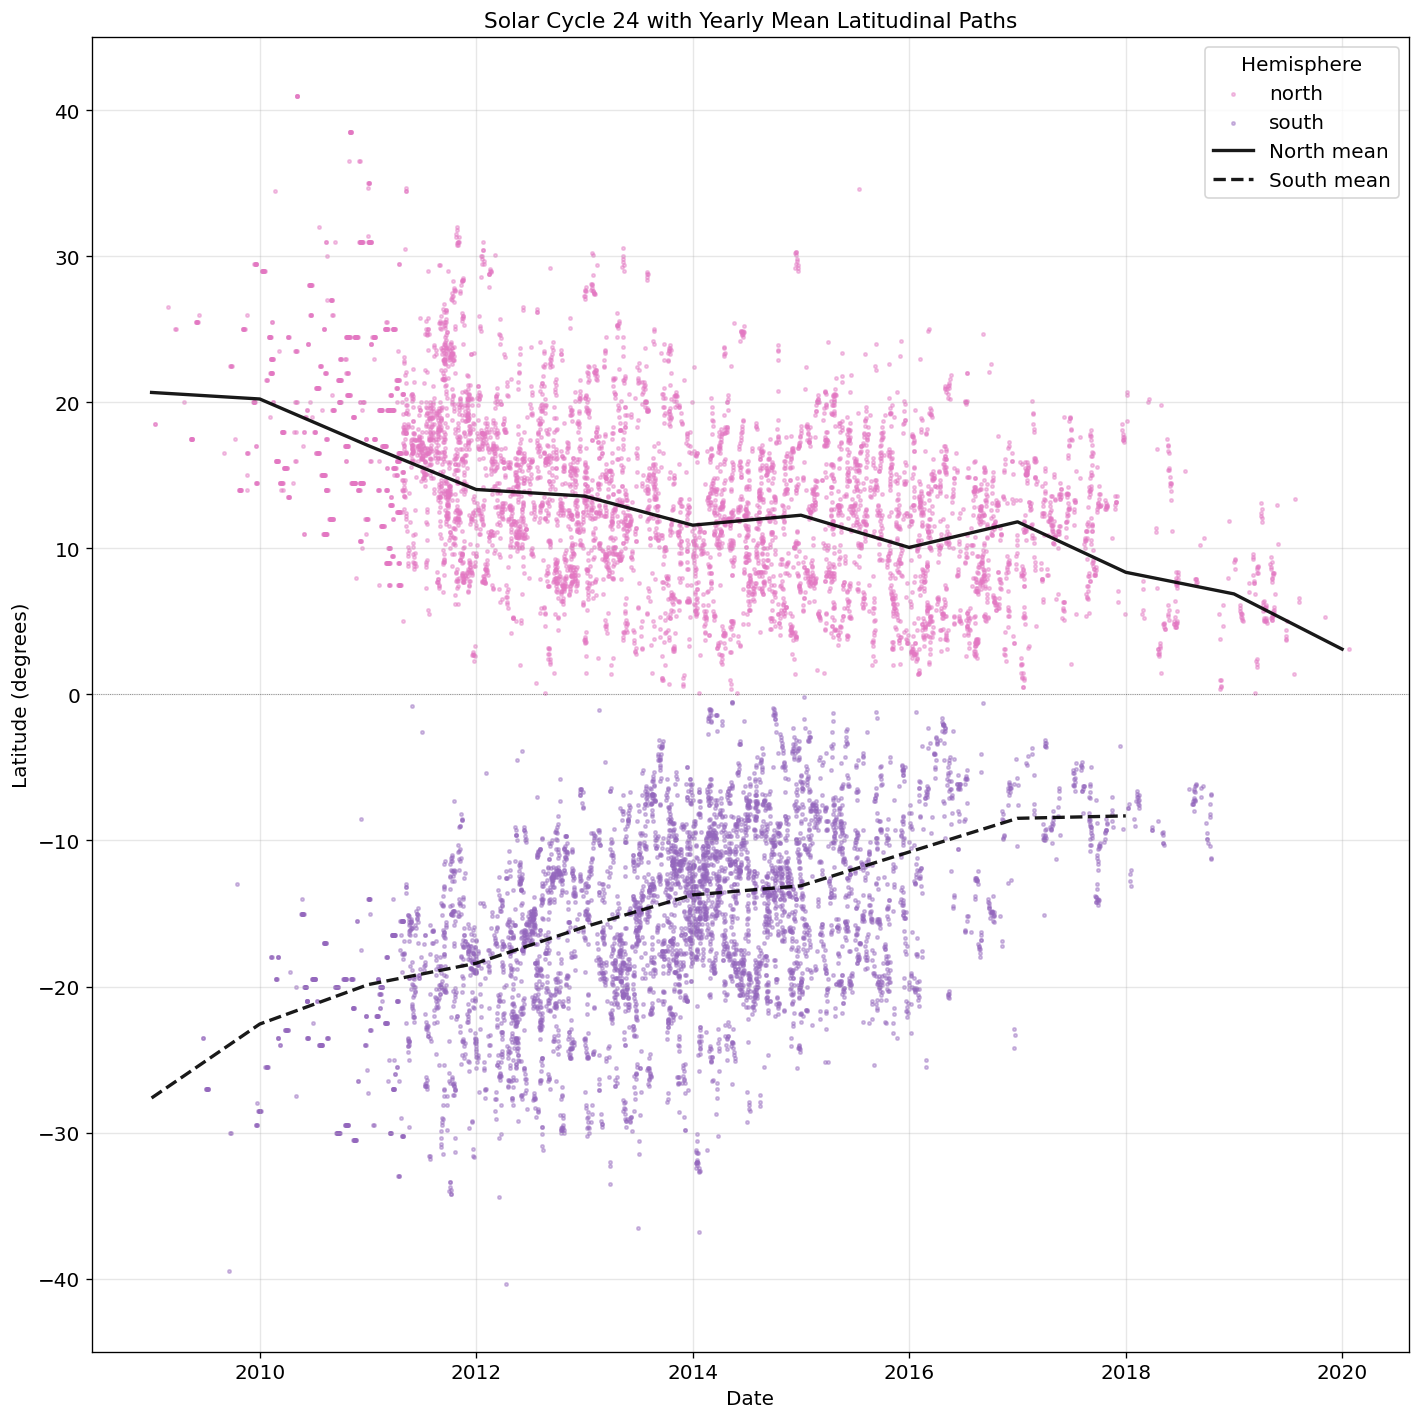

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [21]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:pink"), ("south", "tab:purple")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


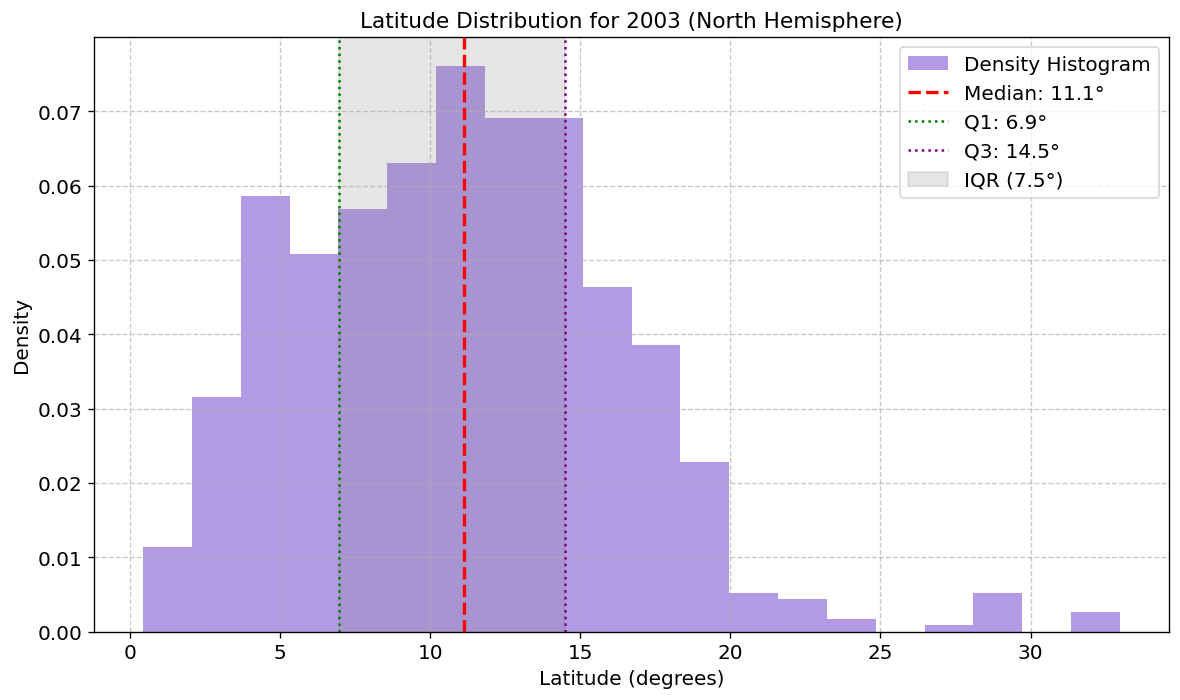

Distribution for 2003 North Hemisphere:
  Median Latitude: 11.1°
  Q1 Latitude: 6.9°
  Q3 Latitude: 14.5°
  Interquartile Range (IQR): 7.5°
  Number of sunspots: 702


In [16]:
import matplotlib.pyplot as plt
import numpy as np

year = 2003
hemisphere_to_plot = 'north'

# Filter the data
df_filtered = df[(df['date'].dt.year == year) & (df['hemisphere'] == hemisphere_to_plot)].copy()
latitudes = df_filtered['latitude']

# Calculate statistics for the plot
median_lat = np.median(latitudes)
q1_lat = np.percentile(latitudes, 25)
q3_lat = np.percentile(latitudes, 75)
iqr = q3_lat - q1_lat

# Plot a histogram of emergence latitudes (density-normalized)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latitudes, bins=20, density=True, alpha=0.7, color='mediumpurple', label='Density Histogram')

# Add vertical lines marking the median, Q1, and Q3, and shade the IQR
# Median Latitude (so the average latitude during the North 2003 year)
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')

# Q1: THis is a value where 25% of the data falls. It marks the end of the 'first quater' of my data
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=1.5, label=f'Q1: {q1_lat:.1f}°')

# Q3 This is a value where 75% of the data falls at, where 25% falls ABOVE Q3.
# It is the beginning of the last quarter of my data.
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=1.5, label=f'Q3: {q3_lat:.1f}°')

# IQR: This is the interquartile Range, where is is the difference between Q3 and Q1.
# It basically means the larger it is the sunspots are emerging over a broader range,
# and a shoter LQR means a more narrow range.
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label=f'IQR ({iqr:.1f}°)')

# Comments: I can see that the LHS has a much more gradual slope (going from the
# average) compared to the RHS, which is much more steep. The IQR shows the range
# of data (which is. ~50%). Something interesting I found when changing the year
# was knowing where I am in the solar cycle. During solar minimum, the LQR is much
# smaller while during solar maximum, it is much larger. It also changes Q3/Q1
# (obviously).

ax.set_title(f'Latitude Distribution for {year} ({hemisphere_to_plot.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Distribution for {year} {hemisphere_to_plot.capitalize()} Hemisphere:")
print(f"  Median Latitude: {median_lat:.1f}°")
print(f"  Q1 Latitude: {q1_lat:.1f}°")
print(f"  Q3 Latitude: {q3_lat:.1f}°")
print(f"  Interquartile Range (IQR): {iqr:.1f}°")
print(f"  Number of sunspots: {len(latitudes)}")

# Note: This code was made with the assistance of Google Gemini. I could have created
# the code myself but since I am a graduate student I don't have as much time to
# give making the code, and find it more benifical to fact check and interpret what
# Gemini gives me. I chose the year and hemisphere.

**Comments from Code Here:**


*   I can see that the LHS has a much more gradual slope (going from the average) compared to the RHS, which is much more steep. The IQR shows the range of data (which is. ~50%). Something interesting I found when changing the year was knowing where I am in the solar cycle. During solar minimum, the LQR is much smaller while during solar maximum, it is much larger. It also changes Q3/Q1 (obviously).
*   This code was made with the assistance of Google Gemini. I could have created the code myself but since I am a graduate student I don't have as much time to give making the code, and find it more benifical to fact check and interpret what Gemini gives me. I chose the year and hemisphere.



## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


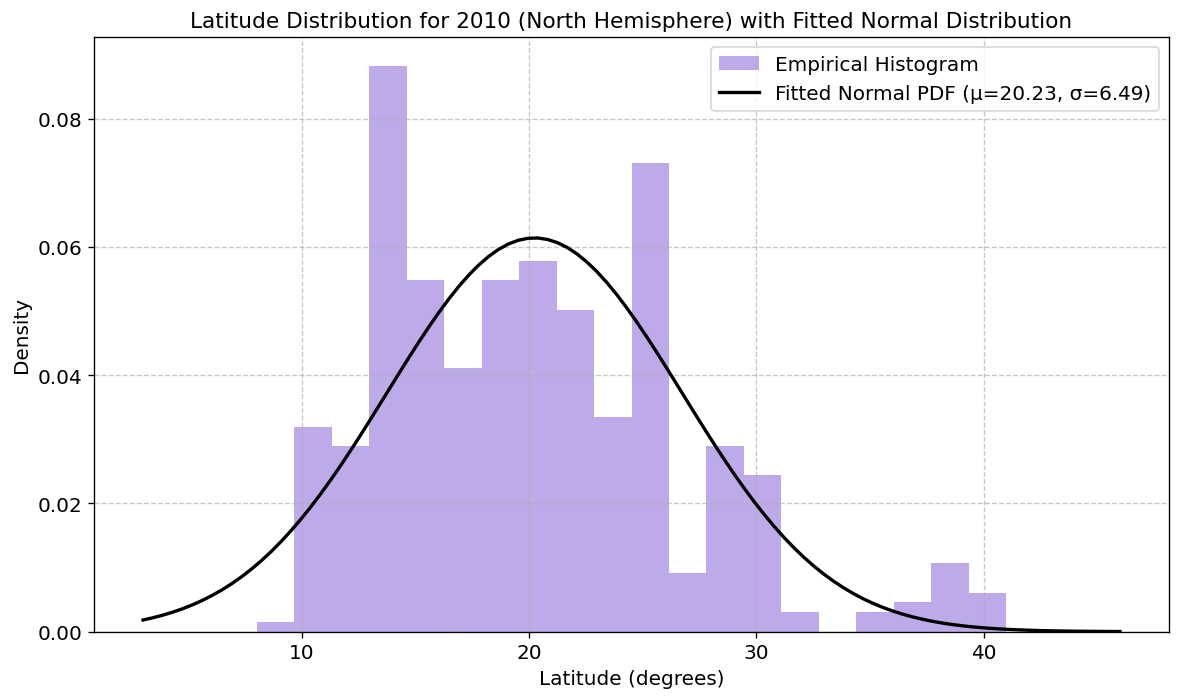

Fitted Normal Distribution Parameters for 2010 North Hemisphere:
  Mean (μ): 20.23 degrees
  Standard Deviation (σ): 6.49 degrees


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Using the same year and hemisphere as Task 6
year = 2010
hemisphere_to_plot = 'north'

# Filter data for the chosen year and hemisphere
df_filtered = df[(df['date'].dt.year == year) & (df['hemisphere'] == hemisphere_to_plot)].copy()
latitudes = df_filtered['latitude']

# Fit a Normal distribution to the data
# Mu is the average (mean) of our curve. The result (for 2003) is 11 degrees. This
# is different than brute force calculating it from task 6 (which was 11.1 degrees).
# This is good because that means our calculations are correct. Sigma is the standard
# deviation of the curve. This was around 5.28 degrees, a little bit smaller than
# IQR. Howver, the standard deviation is not the same as Q3 - Q1, which was more or
# less a defined parameter, not derived from a gaussian curve. I edited the years
# and I found it does well during solar max (this makes sense) and not so great
# during solar min. This is because solar min has more randomized events, while solar
# max has a more narrow, defined number of events (and how powerful they are). You
# can have small and large storms during solar min, but mostly large storms during
# solar max.

# Mu represents the average lat at which sunspots emerge from during each year. Sigma
# represents the spread of sunspot emergence lats around the mean. The smaller sigma
# is, the more precise mu is, and vice versa.
mu, sigma = norm.fit(latitudes)

# Create the histogram (density-normalized) using the same parameters as Task 6 for consistency
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latitudes, bins=20, density=True, alpha=0.6, color='mediumpurple', label='Empirical Histogram')

# Plot the fitted PDF
x = np.linspace(latitudes.min() - 5, latitudes.max() + 5, 100)
p_pdf = norm.pdf(x, mu, sigma)
ax.plot(x, p_pdf, 'k', linewidth=2, label=f'Fitted Normal PDF (μ={mu:.2f}, σ={sigma:.2f})')

ax.set_title(f'Latitude Distribution for {year} ({hemisphere_to_plot.capitalize()} Hemisphere) with Fitted Normal Distribution')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Fitted Normal Distribution Parameters for {year} {hemisphere_to_plot.capitalize()} Hemisphere:")
print(f"  Mean (μ): {mu:.2f} degrees")
print(f"  Standard Deviation (σ): {sigma:.2f} degrees")

# Note: This code was made with the assistance of Google Gemini. I could have created
# the code myself but since I am a graduate student I don't have as much time to
# give making the code, and find it more benifical to fact check and interpret what
# Gemini gives me. I chose the year and hemisphere.

**Comments From Code**


*  Mu is the average (mean) of our curve. The result (for 2003) is 11 degrees. This is different than brute force calculating it from task 6 (which was 11.1 degrees). This is good because that means our calculations are correct. Sigma is the standard deviation of the curve. This was around 5.28 degrees, a little bit smaller than IQR. Howver, the standard deviation is not the same as Q3 - Q1, which was more or less a defined parameter, not derived from a gaussian curve. I edited the years and I found it does well during solar max (this makes sense) and not so great during solar min. This is because solar min has more randomized events, while solar max has a more narrow, defined number of events (and how powerful they are). You can have small and large storms during solar min, but mostly large storms during solar max.

*   Mu represents the average lat at which sunspots emerge from during each year. Sigma represents the spread of sunspot emergence lats around the mean. The smaller sigma is, the more precise mu is, and vice versa.

* Comparing difference year, I notice that as the solar cycle progresses, the mean lat decreases (which is good!). From a physical standpoint, the magnetic fields will wrap around and tighten, causing sunsppot formation to occur near the equator.

*   This code was made with the assistance of Google Gemini. I could have created the code myself but since I am a graduate student I don't have as much time to give making the code, and find it more benifical to fact check and interpret what Gemini gives me. I chose the year and hemisphere.



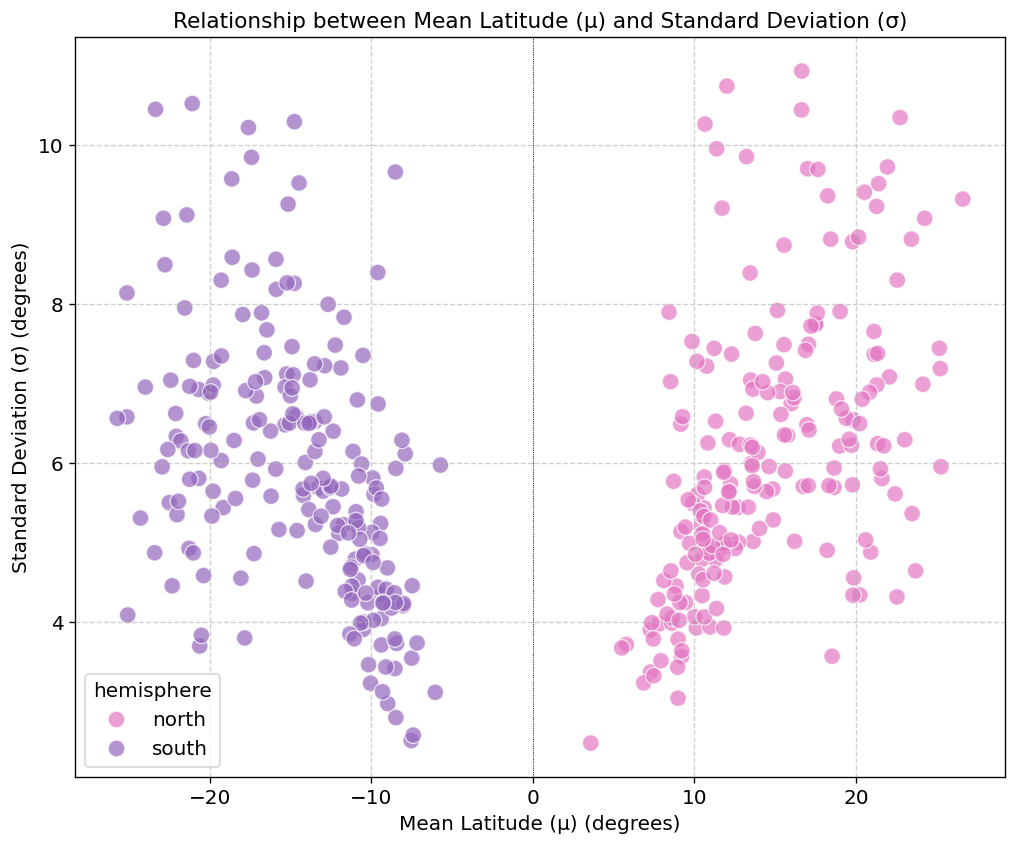

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns # Import seaborn

# EXTRA: Analyze Mu and Sigma across years and cycles

# Prepare an empty list to store the results
mu_sigma_data = []

# Get all unique years and cycles from the DataFrame
# We'll consider years where we have cycle information for more meaningful analysis
all_years = sorted(df['date'].dt.year.unique())

for year in all_years:
    for hemisphere in ['north', 'south']:
        df_yearly_hemi = df[(df['date'].dt.year == year) & (df['hemisphere'] == hemisphere)]

        # Only proceed if there's enough data for the current year and hemisphere
        if len(df_yearly_hemi) > 1:
            latitudes = df_yearly_hemi['latitude']

            # Fit a Normal distribution
            mu, sigma = norm.fit(latitudes)

            # Get the predominant cycle for that year and hemisphere (if available)
            cycle_numbers = df_yearly_hemi['CYCLE'].dropna().unique()
            cycle_number = cycle_numbers[0] if len(cycle_numbers) > 0 else np.nan

            mu_sigma_data.append({
                'year': year,
                'hemisphere': hemisphere,
                'mu': mu,
                'sigma': sigma,
                'cycle': cycle_number
            })

# Convert the list of dictionaries to a DataFrame
mu_sigma_df = pd.DataFrame(mu_sigma_data)

# Mu vs. Sigma for all solar cycles
plt.figure(figsize=(10, 8))
sns.scatterplot(data=mu_sigma_df, x='mu', y='sigma', hue='hemisphere',
                palette={'north': 'tab:pink', 'south': 'tab:purple'}, s=100, alpha=0.7)
plt.title('Relationship between Mean Latitude (μ) and Standard Deviation (σ)')
plt.xlabel('Mean Latitude (μ) (degrees)')
plt.ylabel('Standard Deviation (σ) (degrees)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='k', linestyle=':', linewidth=0.5)
plt.show()

### Discussion for Task 7:

**Does it fit well? Where does it agree with the data and where does it fail?**

The Normal distribution provides a reasonable approximation, especially around the central peak of the histogram. However, it often fails to perfectly capture the asymmetry or any extended tails present in the empirical distribution. For instance, sunspot emergence might have a sharper cutoff at higher latitudes or a more gradual tail towards the equator than a symmetric Gaussian suggests. The 'shoulders' of the histogram might also be under- or over-represented by the smooth Gaussian curve.

**The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?**

*   **μ (mu) - Mean:** In the context of sunspot emergence, μ represents the **average latitude** at which sunspots emerge for the given year and hemisphere. This is a direct measure of the central tendency of sunspot activity.

*   **σ (sigma) - Standard Deviation:** σ represents the **spread or dispersion** of sunspot emergence latitudes around the mean. A smaller σ indicates that sunspots are emerging within a narrower band of latitudes, while a larger σ suggests a wider range of latitudes. Physically, it describes the width of the activity zone.

Discussion for Task 7: I already discussed this earlier.